# Part 3: Streamlit App — Summary & Demonstration (CLIP)

This notebook summarizes the Streamlit app and demonstrates both **Text → Image** and **Image → Text** See results without running the app.

**How to run the app (from project root):**
```bash
streamlit run app/streamlit_app.py

In [1]:

# Imports & Paths
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import CLIPModel, CLIPProcessor

# Resolve project paths (works when this .ipynb lives in notebooks/)
PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
EMB_DIR = PROJECT_ROOT / "embeddings"
DATA_DIR = PROJECT_ROOT / "data" / "flickr8k"
IMAGES_DIR = DATA_DIR / "Images"

IMAGE_EMB_FILE = EMB_DIR / "image_embeddings.npy"
META_FILE = EMB_DIR / "metadata.csv"
TEXT_EMB_FILE = EMB_DIR / "text_embeddings.npy"

MODEL_NAME = "openai/clip-vit-base-patch32"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)

Project root: c:\Nackademin_PIA_24\deep_learning\search_engine
Device: cpu


In [2]:
# Load Embeddings & Metadata

assert IMAGE_EMB_FILE.exists(), f"Missing {IMAGE_EMB_FILE}. Please run Part 1."
assert META_FILE.exists(), f"Missing {META_FILE}. Please run Part 1."
assert IMAGES_DIR.exists(), f"Missing images dir: {IMAGES_DIR}"

image_embs = np.load(IMAGE_EMB_FILE)     # shape [N, D], L2-normalized in Part 1
meta = pd.read_csv(META_FILE)            # columns: image, caption

assert len(meta) == image_embs.shape[0], "Mismatch between metadata rows and embedding rows."

print("Image embeddings shape:", image_embs.shape)
meta.head()

Image embeddings shape: (8091, 512)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
2,1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front o...
3,1003163366_44323f5815.jpg,A man lays on a bench while his dog sits by him .
4,1007129816_e794419615.jpg,A man in an orange hat starring at something .


In [8]:
# Load CLIP

clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME, use_fast=False)

# sanity check: text embedding dimension must match image_embs
with torch.no_grad():
    dummy = clip_processor(text=["hello"], return_tensors="pt").to(DEVICE)
    dim = clip_model.get_text_features(**dummy).shape[-1]
print("Text embedding dim:", dim)
assert image_embs.shape[1] == dim, "Embedding dimension mismatch — ensure same CLIP model as in Part 1."

Text embedding dim: 512


In [9]:
# Helper functions

@torch.no_grad()
def embed_text(query: str) -> np.ndarray:
    """Return [1, D] L2-normalized text embedding."""
    inputs = clip_processor(text=[query], return_tensors="pt", padding=True, truncation=True).to(DEVICE)
    feats = clip_model.get_text_features(**inputs)
    feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    return feats.detach().cpu().numpy()

@torch.no_grad()
def embed_image(pil_img: Image.Image) -> np.ndarray:
    """Return [1, D] L2-normalized image embedding."""
    inputs = clip_processor(images=[pil_img.convert("RGB")], return_tensors="pt").to(DEVICE)
    feats = clip_model.get_image_features(**inputs)
    feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    return feats.detach().cpu().numpy()

def topk_from_scores(scores: np.ndarray, k: int = 5) -> np.ndarray:
    k = min(k, scores.shape[0])
    idx = np.argpartition(scores, -k)[-k:]
    return idx[np.argsort(scores[idx])[::-1]]

def show_top_images_grid(image_names: List[str], cols: int = 5, size=(3.2,3.2)):
    n = len(image_names)
    cols = min(cols, n)
    fig, axes = plt.subplots(1, cols, figsize=(cols*size[0], size[1]))
    if cols == 1:
        axes = [axes]
    for ax, name in zip(axes, image_names):
        path = IMAGES_DIR / name
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(Path(name).name, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_scores(names: List[str], scores: np.ndarray, title="Top-K cosine similarity"):
    plt.figure(figsize=(6,3))
    plt.bar(range(len(names)), scores)
    plt.xticks(range(len(names)), [Path(n).name for n in names], rotation=45, ha="right", fontsize=8)
    plt.ylabel("Cosine similarity")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [10]:
# Build/Load text embeddings for captions

@torch.no_grad()
def build_or_load_text_embeddings(batch_size: int = 128) -> np.ndarray:
    """
    Compute L2-normalized text embeddings for meta['caption'] and cache to TEXT_EMB_FILE.
    If a cached file exists with correct length, load it.
    """
    if TEXT_EMB_FILE.exists():
        tex = np.load(TEXT_EMB_FILE)
        if tex.shape[0] == len(meta) and tex.shape[1] == image_embs.shape[1]:
            print("Loaded cached text embeddings:", tex.shape)
            return tex
        else:
            print("Cached text embeddings mismatched. Recomputing...")

    captions = meta["caption"].astype(str).tolist()
    all_vecs = []
    for start in range(0, len(captions), batch_size):
        chunk = captions[start:start+batch_size]
        inputs = clip_processor(text=chunk, return_tensors="pt", padding=True, truncation=True).to(DEVICE)
        feats = clip_model.get_text_features(**inputs)
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
        all_vecs.append(feats.detach().cpu().numpy())
    text_embs = np.concatenate(all_vecs, axis=0)
    np.save(TEXT_EMB_FILE, text_embs)
    print("Saved text embeddings to:", TEXT_EMB_FILE, "shape:", text_embs.shape)
    return text_embs

text_embs = build_or_load_text_embeddings()
text_embs.shape

Loaded cached text embeddings: (8091, 512)


(8091, 512)

In [11]:
# Text → Image demo

QUERY = "a brown dog running on the beach"
TOPK = 5

q_emb = embed_text(QUERY)               # [1, D]
scores = image_embs @ q_emb[0]          # [N]
idx = topk_from_scores(scores, k=TOPK)

top_images = meta.loc[idx, "image"].tolist()
top_scores = scores[idx]

print("Query:", QUERY)
pd.DataFrame({"image": top_images, "cosine": top_scores}).sort_values("cosine", ascending=False).reset_index(drop=True)

Query: a brown dog running on the beach


,image,cosine
0,2089442007_6fc798548c.jpg,0.368728
1,488416045_1c6d903fe0.jpg,0.355478
2,3235746553_a40416c00e.jpg,0.354374
3,489372715_ce52da796a.jpg,0.351511
4,467960888_6943257534.jpg,0.350715


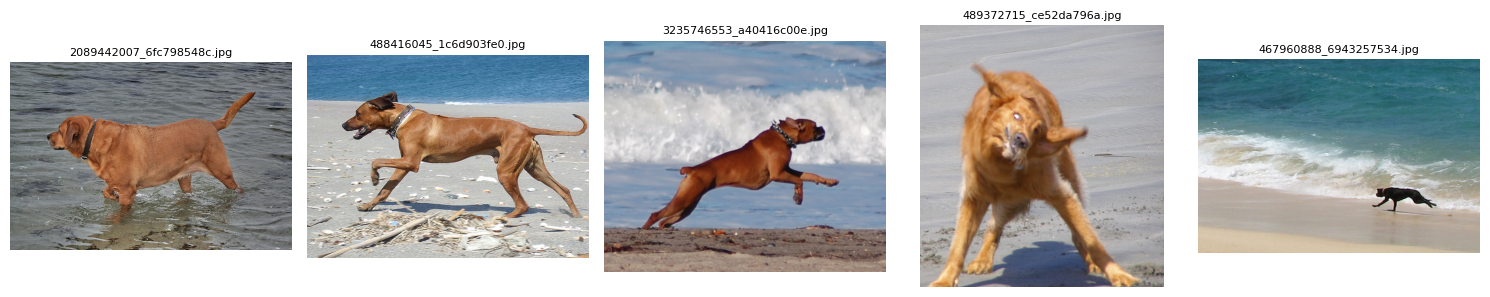

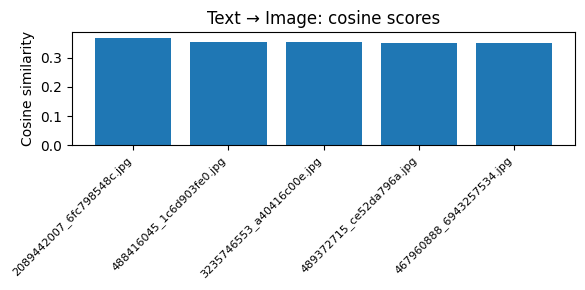

In [12]:
# Visualize results (images + score chart)

show_top_images_grid(top_images, cols=5, size=(3.0,3.0))
plot_scores(top_images, top_scores, title="Text → Image: cosine scores")

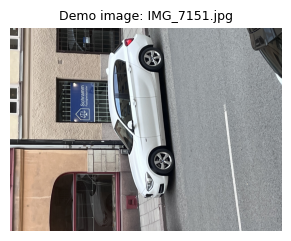

,caption,cosine
0,A street view with cars and buildings .,0.282662
1,A person in red is opening a red car 's door i...,0.279977
2,A man lies on a street with his head and shoul...,0.278194
3,A car is parked in a graffiti filled street .,0.272968
4,A person drives in a red car .,0.270375


In [16]:
# Image → Text demo (choose a specific image by filename)

from pathlib import Path

# Point to your specific image. Adjust the path if needed.
DEMO_IMAGE = PROJECT_ROOT / "data" / "IMG_7151.jpg"   # e.g., project-root/data/IMG_7151.jpg

# Safety check
assert DEMO_IMAGE.exists(), f"Image not found: {DEMO_IMAGE}"

# Open and show the image
demo_img = Image.open(DEMO_IMAGE).convert("RGB")
plt.figure(figsize=(3.5, 3.0))
plt.imshow(demo_img)
plt.axis("off")
plt.title(f"Demo image: {DEMO_IMAGE.name}", fontsize=9)
plt.show()

# Embed the image and retrieve the most similar captions
TOPK = 5
img_emb = embed_image(demo_img)          # [1, D]
scores = text_embs @ img_emb[0]          # [N]
idx = topk_from_scores(scores, k=TOPK)

# Prepare a results table with only the texts (and cosine scores).
rows = meta.loc[idx, ["caption", "image"]].copy()
rows["cosine"] = scores[idx]
rows = rows.sort_values("cosine", ascending=False).reset_index(drop=True)

# Display just the captions and scores
rows[["caption", "cosine"]]


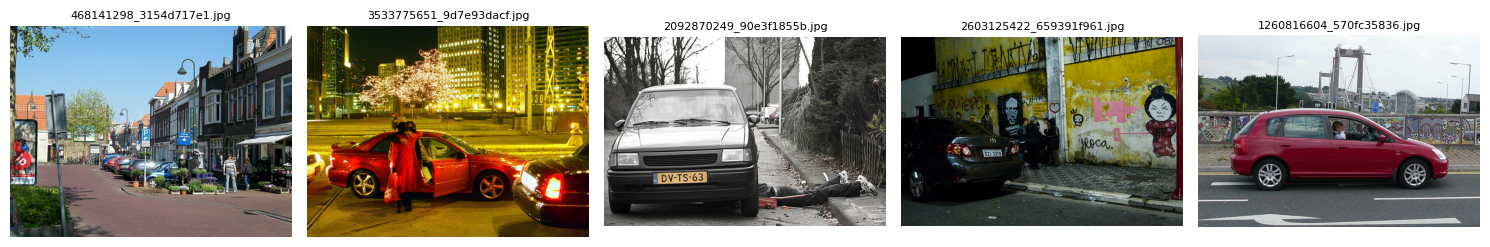

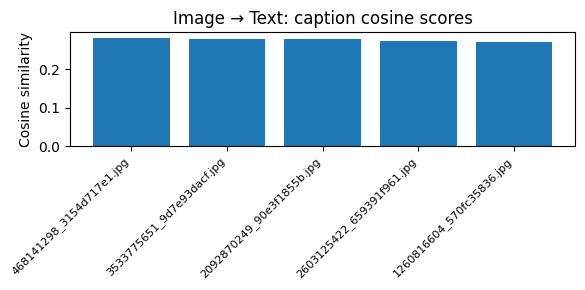

In [17]:
# Show the images behind returned captions

# Display the images that own the top captions (context)
ctx_images = rows["image"].tolist()
ctx_scores = rows["cosine"].values
show_top_images_grid(ctx_images, cols=5, size=(3.0,3.0))
plot_scores(ctx_images, ctx_scores, title="Image → Text: caption cosine scores")

### What the results suggest

- **Text → Image:** CLIP aligns the text query embedding to the image embedding space.
  The top results often share the same high-level objects, scenes, or actions as the query (e.g., *dog*, *running*, *beach*).
- **Image → Text:** The uploaded (or demo) image is embedded and matched against caption embeddings.
  The top captions typically share salient concepts from the picture.

Since we use cosine similarity on **L2-normalized** embeddings, rankings reflect angular distance,
which is standard practice for retrieval with CLIP.